In [5]:
import torch
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [6]:
semantic_model = torchvision.models.segmentation.deeplabv3_resnet101(pretrained=True)
semantic_model.eval()

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

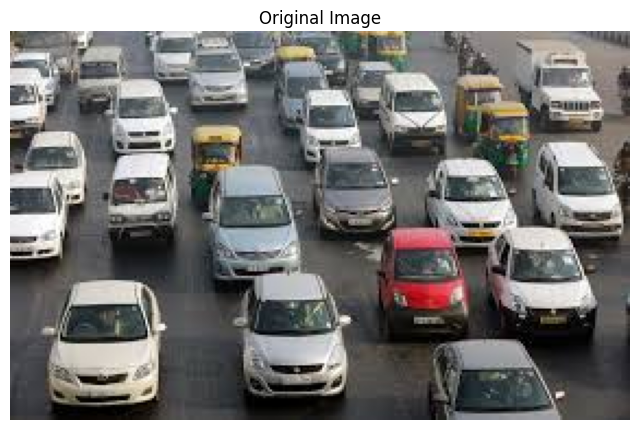

In [8]:
image_path = "test.jpg"   # change to your actual file name
image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [9]:
transform = transforms.Compose([
    transforms.ToTensor()
])

img_tensor = transform(image).unsqueeze(0)

In [10]:
with torch.no_grad():
    output = semantic_model(img_tensor)['out'][0]

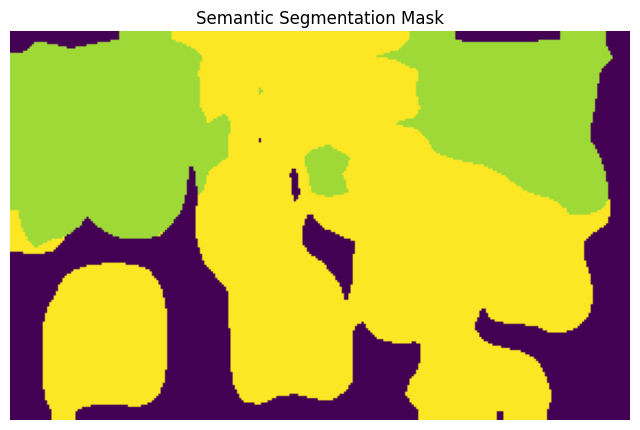

In [11]:
output_predictions = output.argmax(0).byte().cpu().numpy()

plt.figure(figsize=(8, 6))
plt.imshow(output_predictions)
plt.title("Semantic Segmentation Mask")
plt.axis("off")
plt.show()

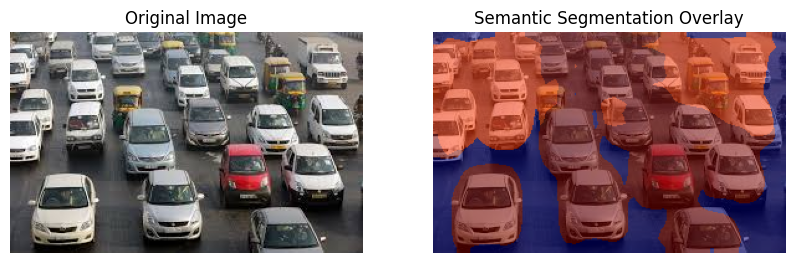

In [12]:
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image)
plt.imshow(output_predictions, alpha=0.5, cmap='jet')
plt.title("Semantic Segmentation Overlay")
plt.axis("off")

plt.show()

In [13]:
instance_model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)
instance_model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 156MB/s]


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [14]:
with torch.no_grad():
    predictions = instance_model(img_tensor)

In [15]:
print(predictions[0].keys())

dict_keys(['boxes', 'labels', 'scores', 'masks'])


In [17]:
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane',
    'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
    'N/A', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog',
    'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
    'N/A', 'backpack', 'umbrella', 'N/A', 'N/A', 'handbag', 'tie',
    'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite',
    'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog',
    'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed',
    'N/A', 'dining table', 'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop',
    'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven',
    'toaster', 'sink', 'refrigerator', 'N/A', 'book', 'clock', 'vase',
    'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

Detected: bus, Confidence: 0.97
Detected: truck, Confidence: 0.97
Detected: car, Confidence: 0.96
Detected: bus, Confidence: 0.96
Detected: car, Confidence: 0.95
Detected: bus, Confidence: 0.92
Detected: car, Confidence: 0.92
Detected: car, Confidence: 0.91
Detected: car, Confidence: 0.90
Detected: car, Confidence: 0.90
Detected: car, Confidence: 0.87
Detected: car, Confidence: 0.87
Detected: bus, Confidence: 0.86
Detected: car, Confidence: 0.86
Detected: car, Confidence: 0.80
Detected: truck, Confidence: 0.72
Detected: truck, Confidence: 0.71
Detected: truck, Confidence: 0.70
Detected: car, Confidence: 0.69
Detected: truck, Confidence: 0.68
Detected: truck, Confidence: 0.66
Detected: truck, Confidence: 0.65
Detected: car, Confidence: 0.64
Detected: car, Confidence: 0.63
Detected: car, Confidence: 0.63
Detected: truck, Confidence: 0.62
Detected: truck, Confidence: 0.61
Detected: car, Confidence: 0.59
Detected: car, Confidence: 0.59
Detected: car, Confidence: 0.59
Detected: car, Confide

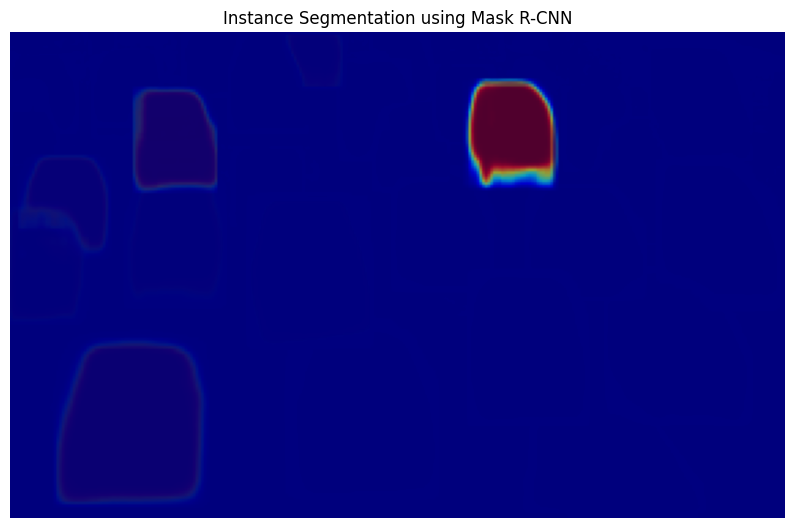

In [18]:
image_np = np.array(image)

plt.figure(figsize=(10, 8))
plt.imshow(image_np)

threshold = 0.5

for i in range(len(predictions[0]['masks'])):
    score = predictions[0]['scores'][i].item()

    if score > threshold:
        mask = predictions[0]['masks'][i, 0].mul(255).byte().cpu().numpy()
        label = predictions[0]['labels'][i].item()
        class_name = COCO_CLASSES[label]

        plt.imshow(mask, alpha=0.4, cmap='jet')
        print(f"Detected: {class_name}, Confidence: {score:.2f}")

plt.title("Instance Segmentation using Mask R-CNN")
plt.axis("off")
plt.show()

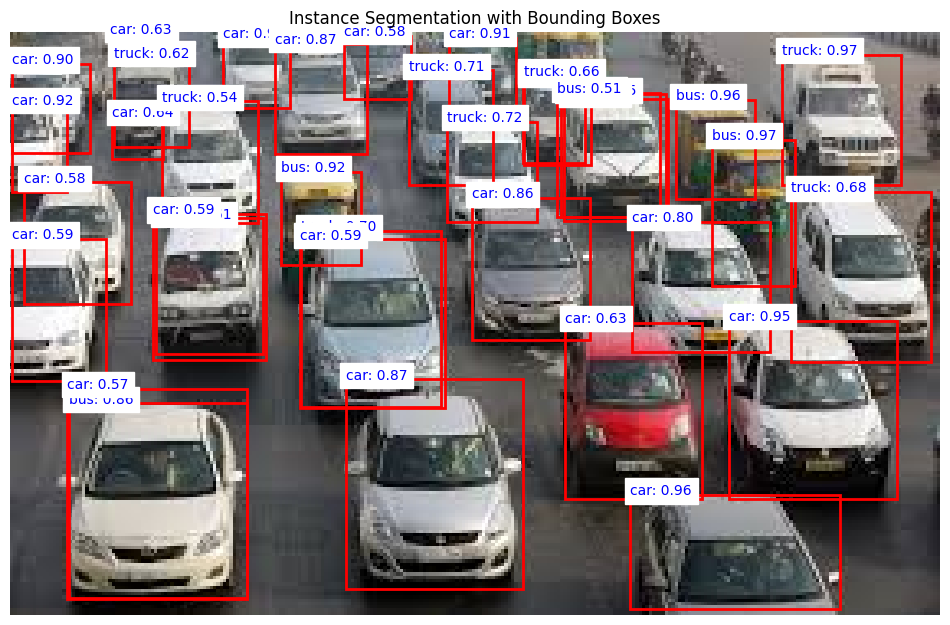

In [19]:
import matplotlib.patches as patches

fig, ax = plt.subplots(1, figsize=(12, 8))
ax.imshow(image_np)

for i in range(len(predictions[0]['boxes'])):
    score = predictions[0]['scores'][i].item()

    if score > threshold:
        box = predictions[0]['boxes'][i].cpu().numpy()
        label = predictions[0]['labels'][i].item()
        class_name = COCO_CLASSES[label]

        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1, f"{class_name}: {score:.2f}",
                color='blue', fontsize=10, backgroundcolor='white')

plt.title("Instance Segmentation with Bounding Boxes")
plt.axis("off")
plt.show()